In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2

2026-06-07 17:55:15.523571: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780854915.911236      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780854916.025053      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780854916.826192      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780854916.826254      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780854916.826258      58 computation_placer.cc:177] computation placer alr

In [4]:
train_dir = "/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/train"

test_dir = "/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/test"

In [6]:
IMG_HEIGHT = 128
IMG_WIDTH = 128

BATCH_SIZE = 16

EPOCHS = 10

NUM_CLASSES = 6

In [7]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,

    shear_range=0.2,
    zoom_range=0.2,

    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [8]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128,128),

    batch_size=16,

    class_mode='categorical',

    subset='training'
)

Found 8723 images belonging to 6 classes.


In [9]:
valid_generator = train_datagen.flow_from_directory(
    train_dir,

    target_size=(128,128),

    batch_size=16,

    class_mode='categorical',

    subset='validation',

    shuffle=False
)

Found 2178 images belonging to 6 classes.


In [10]:
test_generator = test_datagen.flow_from_directory(
    test_dir,

    target_size=(128,128),

    batch_size=16,

    class_mode='categorical',

    shuffle=False
)

Found 2698 images belonging to 6 classes.


In [11]:
print(train_generator.class_indices)

{'freshapples': 0, 'freshbanana': 1, 'freshoranges': 2, 'rottenapples': 3, 'rottenbanana': 4, 'rottenoranges': 5}


In [12]:
cnn_model = Sequential([
    Conv2D(32,(3,3),activation='relu',
           input_shape=(128,128,3)),

    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),

    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),

    MaxPooling2D(2,2),

    Flatten(),

    Dense(256,activation='relu'),

    Dropout(0.5),

    Dense(NUM_CLASSES,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-06-07 17:56:31.252426: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [13]:
cnn_model.compile(
    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [14]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,517,574 (24.86 MB)

 Trainable params: 6,517,574 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
early_stop = EarlyStopping(
    monitor='val_loss',

    patience=5,

    restore_best_weights=True
)

In [19]:
history_cnn = cnn_model.fit(
    train_generator,

    validation_data=valid_generator,

    epochs=10,

    callbacks=[early_stop]
)

Epoch 1/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 234s 424ms/step - accuracy: 0.6635 - loss: 0.8983 - val_accuracy: 0.8365 - val_loss: 0.4533
Epoch 2/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 201s 369ms/step - accuracy: 0.8068 - loss: 0.5342 - val_accuracy: 0.8627 - val_loss: 0.3690
Epoch 3/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 210s 384ms/step - accuracy: 0.8528 - loss: 0.4121 - val_accuracy: 0.8563 - val_loss: 0.3973
Epoch 4/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 196s 358ms/step - accuracy: 0.8653 - loss: 0.3716 - val_accuracy: 0.8857 - val_loss: 0.3123
Epoch 5/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 197s 361ms/step - accuracy: 0.8817 - loss: 0.3292 - val_accuracy: 0.9040 - val_loss: 0.2507
Epoch 6/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 197s 360ms/step - accuracy: 0.8909 - loss: 0.3071 - val_accuracy: 0.8880 - val_loss: 0.2798
Epoch 7/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 199s 363ms/step - accuracy: 0.9015 - loss: 0.2806 - val_accuracy: 0.9109 - val_loss: 0.2647
Epoch 8/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 202s 369ms/step - accuracy: 0.9109 -

In [20]:
cnn_model.evaluate(test_generator)

169/169 ━━━━━━━━━━━━━━━━━━━━ 31s 184ms/step - accuracy: 0.9563 - loss: 0.1321


[0.1321037858724594, 0.9562638998031616]

In [21]:
predictions = cnn_model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)

y_true = test_generator.classes

169/169 ━━━━━━━━━━━━━━━━━━━━ 23s 133ms/step


In [22]:
cm = confusion_matrix(y_true,y_pred)

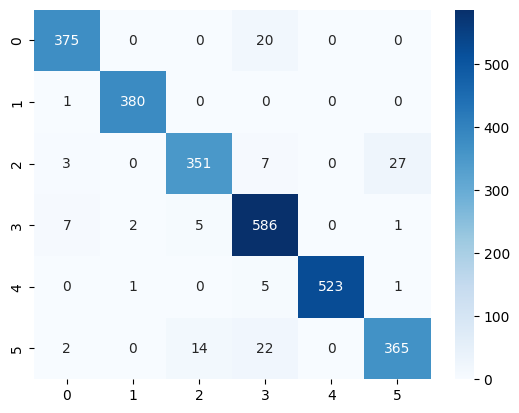

In [23]:
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.savefig("cnn_confusion_matrix.png")
plt.show()

In [24]:
print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_generator.class_indices.keys())
))

               precision    recall  f1-score   support

  freshapples       0.97      0.95      0.96       395
  freshbanana       0.99      1.00      0.99       381
 freshoranges       0.95      0.90      0.93       388
 rottenapples       0.92      0.98      0.94       601
 rottenbanana       1.00      0.99      0.99       530
rottenoranges       0.93      0.91      0.92       403

     accuracy                           0.96      2698
    macro avg       0.96      0.95      0.96      2698
 weighted avg       0.96      0.96      0.96      2698



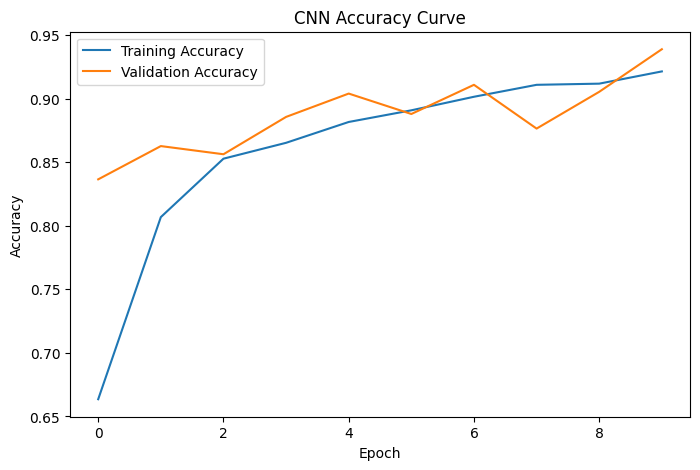

In [25]:
plt.figure(figsize=(8,5))

plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')

plt.title('CNN Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.savefig('cnn_accuracy_curve.png')

plt.show()

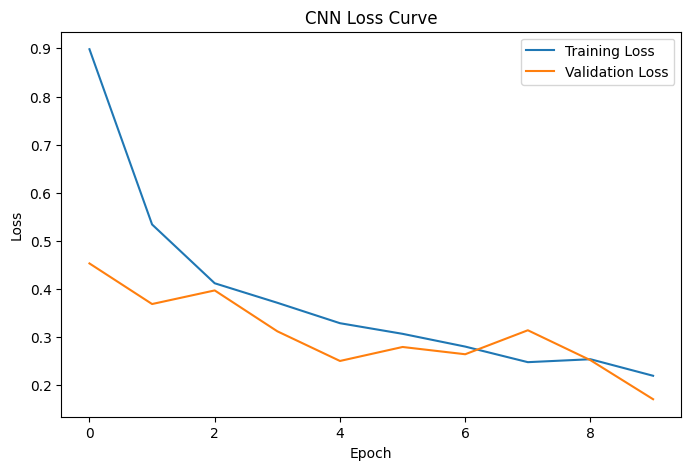

In [26]:
plt.figure(figsize=(8,5))

plt.plot(history_cnn.history['loss'],
         label='Training Loss')

plt.plot(history_cnn.history['val_loss'],
         label='Validation Loss')

plt.title('CNN Loss Curve')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.savefig('cnn_loss_curve.png')

plt.show()

In [40]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [41]:
mobilenet_model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(NUM_CLASSES, activation='softmax')

])

mobilenet_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [42]:
mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_mobile = mobilenet_model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10
)

Epoch 1/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 162s 287ms/step - accuracy: 0.8725 - loss: 0.3608 - val_accuracy: 0.9504 - val_loss: 0.1328
Epoch 2/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 147s 268ms/step - accuracy: 0.9331 - loss: 0.1909 - val_accuracy: 0.9747 - val_loss: 0.0720
Epoch 3/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 153s 280ms/step - accuracy: 0.9453 - loss: 0.1547 - val_accuracy: 0.9780 - val_loss: 0.0713
Epoch 4/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 147s 269ms/step - accuracy: 0.9517 - loss: 0.1383 - val_accuracy: 0.9789 - val_loss: 0.0628
Epoch 5/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 141s 259ms/step - accuracy: 0.9513 - loss: 0.1301 - val_accuracy: 0.9812 - val_loss: 0.0466
Epoch 6/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 145s 266ms/step - accuracy: 0.9608 - loss: 0.1101 - val_accuracy: 0.9821 - val_loss: 0.0529
Epoch 7/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 140s 257ms/step - accuracy: 0.9574 - loss: 0.1225 - val_accuracy: 0.9830 - val_loss: 0.0443
Epoch 8/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 143s 261ms/step - accuracy: 0.9633 -

In [43]:
loss_mobile, accuracy_mobile = mobilenet_model.evaluate(test_generator)

print("MobileNetV2 Accuracy =", accuracy_mobile)

print()

print("Custom CNN Accuracy =", accuracy_cnn)

print()

print("Difference =", accuracy_mobile - accuracy_cnn)

169/169 ━━━━━━━━━━━━━━━━━━━━ 23s 135ms/step - accuracy: 0.9815 - loss: 0.0477
MobileNetV2 Accuracy = 0.9814677834510803

Custom CNN Accuracy = 0.9562638998031616

Difference = 0.0252038836479187


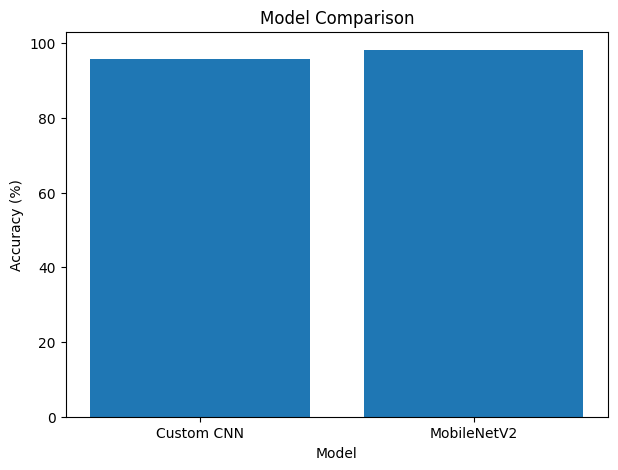

In [44]:
cnn_model.save("cnn_model.h5")

mobilenet_model.save("mobilenet_model.h5")


models = ['Custom CNN', 'MobileNetV2']

accuracies = [
    accuracy_cnn*100,
    accuracy_mobile*100
]

plt.figure(figsize=(7,5))

plt.bar(models, accuracies)

plt.xlabel("Model")

plt.ylabel("Accuracy (%)")

plt.title("Model Comparison")

plt.savefig("model_comparison.png")

plt.show()

In [47]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

In [49]:
y_true_bin = label_binarize(
    y_true,
    classes=[0,1,2,3,4,5]
)

y_pred_prob = predictions

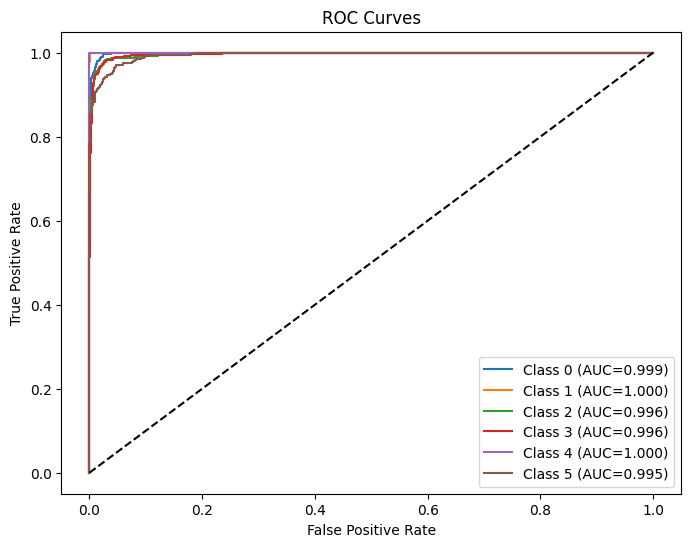

In [50]:
plt.figure(figsize=(8,6))

for i in range(NUM_CLASSES):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:,i],
        y_pred_prob[:,i]
    )

    roc_auc = auc(fpr,tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'Class {i} (AUC={roc_auc:.3f})'
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")

plt.legend()

plt.savefig("roc_curve.png")

plt.show()

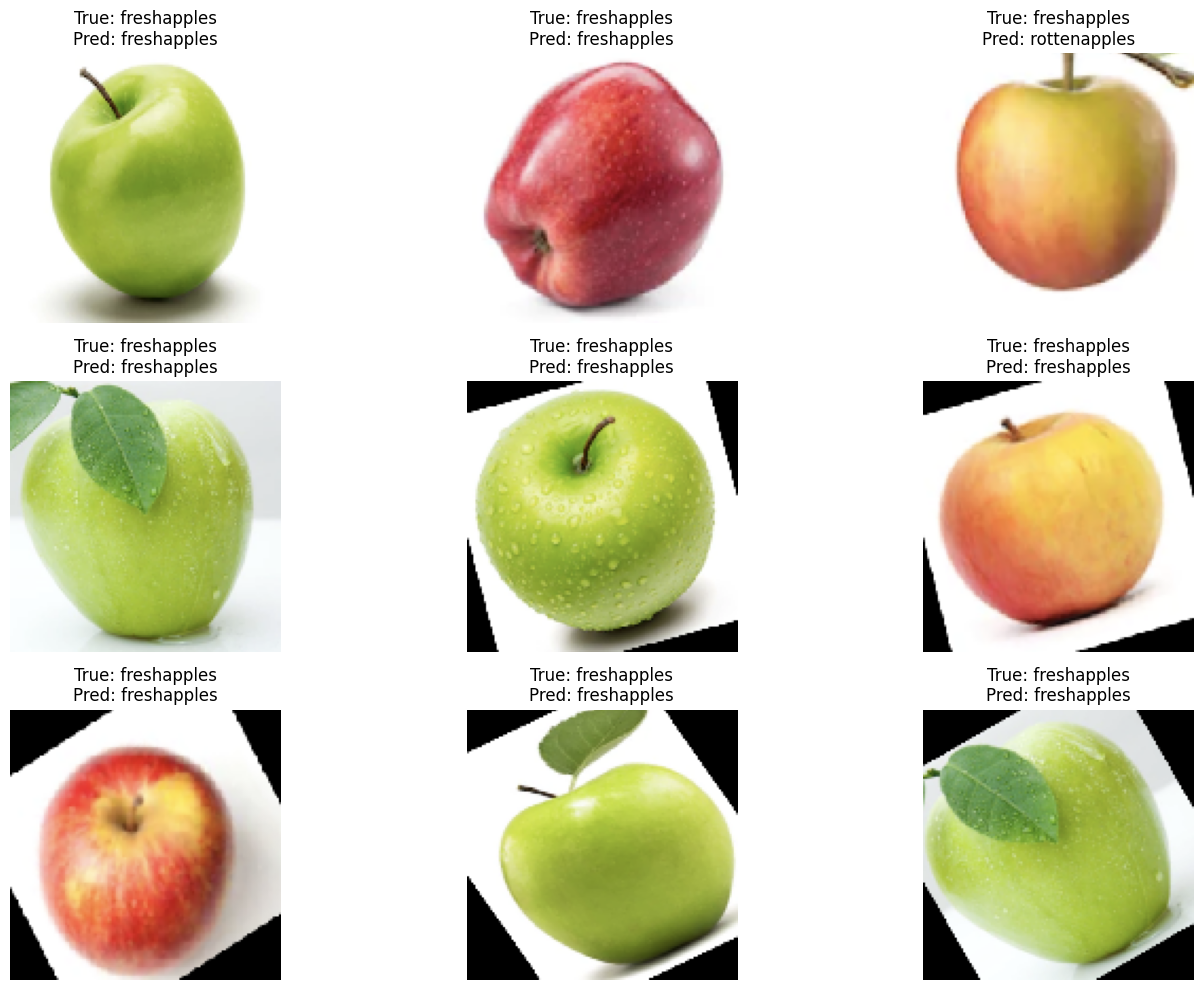

In [51]:
class_names = list(test_generator.class_indices.keys())

plt.figure(figsize=(15,10))

for i in range(9):

    image, label = test_generator[i]

    img = image[0]

    pred = cnn_model.predict(
        np.expand_dims(img, axis=0),
        verbose=0
    )

    pred_class = class_names[np.argmax(pred)]

    true_class = class_names[np.argmax(label[0])]

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.title(
        f"True: {true_class}\nPred: {pred_class}"
    )

    plt.axis('off')

plt.tight_layout()

plt.savefig("sample_predictions.png")

plt.show()

In [52]:
misclassified = np.where(y_true != y_pred)[0]

print("Number of misclassified images:",
      len(misclassified))

Number of misclassified images: 118


ValueError: Asked to retrieve element 171, but the Sequence has length 169

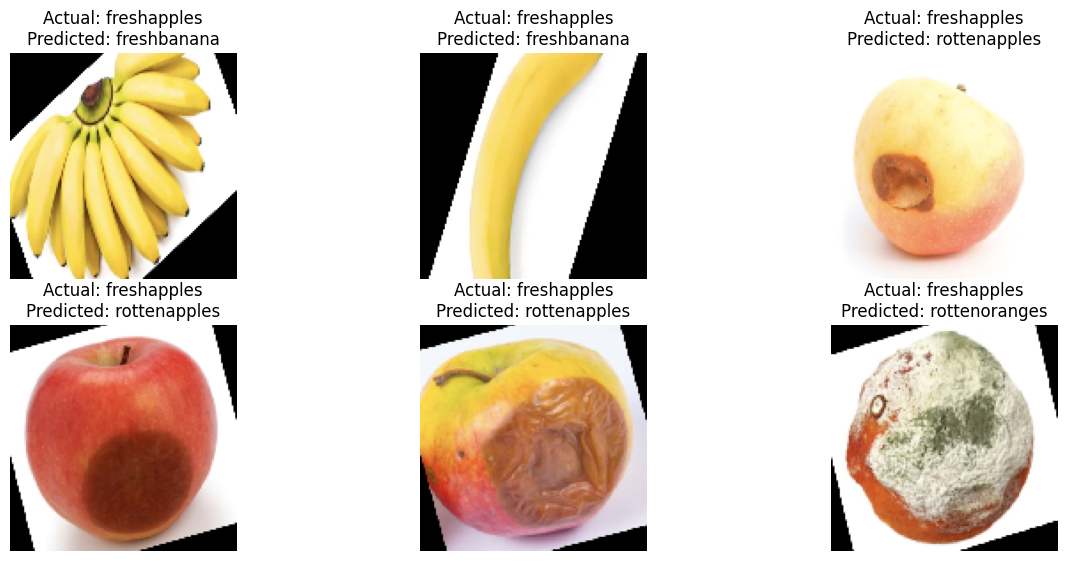

In [53]:
plt.figure(figsize=(15,10))

for i, idx in enumerate(misclassified[:9]):

    img, label = test_generator[idx]

    img = img[0]

    pred = np.argmax(
        cnn_model.predict(
            np.expand_dims(img,0),
            verbose=0
        )
    )

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.title(
        f"Actual: {class_names[y_true[idx]]}\nPredicted: {class_names[pred]}"
    )

    plt.axis('off')

plt.tight_layout()

plt.savefig("misclassified_images.png")

plt.show()

In [54]:
print("========== FINAL RESULTS ==========")

print()

print(f"Custom CNN Accuracy      : {accuracy_cnn*100:.2f}%")

print(f"MobileNetV2 Accuracy     : {accuracy_mobile*100:.2f}%")

print()

if accuracy_mobile > accuracy_cnn:
    print("MobileNetV2 performed better.")
else:
    print("Custom CNN performed better.")

========== FINAL RESULTS ==========

Custom CNN Accuracy      : 95.63%
MobileNetV2 Accuracy     : 98.15%

MobileNetV2 performed better.
